In [8]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 

In [9]:
df = pd.read_csv(r"D:\AIML_MSIS\Applied Machine Learning\Lab_Assignment\LAB 4\diabetes.csv")

In [10]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [11]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [12]:
x = df.iloc[:, :-1].values
x

array([[  6.   , 148.   ,  72.   , ...,  33.6  ,   0.627,  50.   ],
       [  1.   ,  85.   ,  66.   , ...,  26.6  ,   0.351,  31.   ],
       [  8.   , 183.   ,  64.   , ...,  23.3  ,   0.672,  32.   ],
       ...,
       [  5.   , 121.   ,  72.   , ...,  26.2  ,   0.245,  30.   ],
       [  1.   , 126.   ,  60.   , ...,  30.1  ,   0.349,  47.   ],
       [  1.   ,  93.   ,  70.   , ...,  30.4  ,   0.315,  23.   ]],
      shape=(768, 8))

In [13]:
y = df.iloc[:,-1].values
y

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1,

In [14]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split( x, y, test_size = 0.25, random_state = 0)


In [15]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)
x_test

array([[-0.82986389,  2.4576282 ,  0.33249916, ...,  1.34420526,
         2.78665365, -0.96584853],
       [-0.53768687, -0.44693118,  0.2272108 , ...,  0.17490974,
        -0.19434743, -0.88246592],
       [ 0.04666716, -1.42564141, -0.40451932, ...,  0.22520202,
        -0.23349189, -0.71570071],
       ...,
       [-0.82986389, -0.38378859, -0.50980767, ..., -0.85608201,
         1.4406865 , -1.04923114],
       [-0.24550986,  0.21606607,  0.43778751, ..., -1.39672402,
        -0.60385869,  1.7857775 ],
       [ 0.33884418, -1.04678584,  0.43778751, ..., -0.57947447,
        -0.63396981,  0.28489057]], shape=(192, 8))

In [16]:
from sklearn.tree import DecisionTreeClassifier

classifier = DecisionTreeClassifier( criterion = 'entropy', random_state = 0)

classifier.fit(x_train , y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [17]:
y_pred = classifier.predict(x_test)
y_pred

array([1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0])

In [18]:
y_test

array([1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0])

In [19]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cm = confusion_matrix(y_pred, y_test)
cm

array([[105,  18],
       [ 25,  44]])

In [20]:
Accuracy = accuracy_score(y_test, y_pred)
print("Accuracy : ", Accuracy*100,'%')

Accuracy :  77.60416666666666 %


In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.81      0.83       130
           1       0.64      0.71      0.67        62

    accuracy                           0.78       192
   macro avg       0.75      0.76      0.75       192
weighted avg       0.78      0.78      0.78       192



In [22]:
exist = np.array([[5,116,74,0,0,25.6,0.201,30]])

new = np.array([[3, 120, 78, 0, 0, 26, 0.198, 28]])

exist_scaled = sc.transform(exist)
new_scaled = sc.transform(new)

pred1 = classifier.predict(exist_scaled)
pred2 = classifier.predict(new_scaled)

if pred1[0] == 1:
    print("New one is correctly classified")
else:
    print("Not correctly classified")
    
if pred2[0] == 1:
    print("New one is correctly classified")
else:
    print("Not correctly classified")

Not correctly classified
Not correctly classified


[Text(0.40658602150537637, 0.9736842105263158, 'x[1] <= 0.074\nentropy = 0.941\nsamples = 576\nvalue = [370, 206]'),
 Text(0.12063172043010753, 0.9210526315789473, 'x[5] <= -0.724\nentropy = 0.685\nsamples = 329\nvalue = [269, 60]'),
 Text(0.26360887096774194, 0.9473684210526316, 'True  '),
 Text(0.021505376344086023, 0.868421052631579, 'x[6] <= 0.623\nentropy = 0.087\nsamples = 92\nvalue = [91, 1]'),
 Text(0.010752688172043012, 0.8157894736842105, 'entropy = 0.0\nsamples = 76\nvalue = [76, 0]'),
 Text(0.03225806451612903, 0.8157894736842105, 'x[6] <= 0.714\nentropy = 0.337\nsamples = 16\nvalue = [15, 1]'),
 Text(0.021505376344086023, 0.7631578947368421, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.043010752688172046, 0.7631578947368421, 'entropy = 0.0\nsamples = 15\nvalue = [15, 0]'),
 Text(0.21975806451612903, 0.868421052631579, 'x[7] <= -0.424\nentropy = 0.81\nsamples = 237\nvalue = [178, 59]'),
 Text(0.0967741935483871, 0.8157894736842105, 'x[5] <= -0.158\nentropy = 0.549

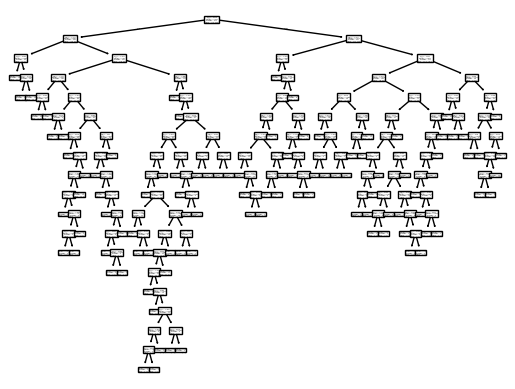

In [23]:
from sklearn import tree
tree.plot_tree(classifier)

In [24]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


In [25]:
x_features = df.iloc[:, :-1].values
y_target = df.iloc[:, -1].values

In [26]:
max_depths = [12, 18, 19]
k_folds = [4, 5, 6]

results = []


In [27]:
for k in k_folds:
    for depth in max_depths:
        skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=0)
        
        fold_accuracy = []
        fold_precision = []
        fold_recall = []
        fold_f1 = []
        
        for train_idx, val_idx in skf.split(x_features, y_target):
            x_train_fold, x_val_fold = x_features[train_idx], x_features[val_idx]
            y_train_fold, y_val_fold = y_target[train_idx], y_target[val_idx]
            
            sc = StandardScaler()
            x_train_scaled = sc.fit_transform(x_train_fold)
            x_val_scaled = sc.transform(x_val_fold)
        
            classifier_model = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=0)
            classifier_model.fit(x_train_scaled, y_train_fold)
            
         
            y_pred = classifier_model.predict(x_val_scaled)
            
            fold_accuracy.append(accuracy_score(y_val_fold, y_pred))
            fold_precision.append(precision_score(y_val_fold, y_pred, zero_division=0))
            fold_recall.append(recall_score(y_val_fold, y_pred, zero_division=0))
            fold_f1.append(f1_score(y_val_fold, y_pred, zero_division=0))
            
        results.append({
            "N_splits (K)": k,
            "Max Depth": depth,
            "Avg Accuracy (%)": round(np.mean(fold_accuracy) * 100, 2),
            "Avg Precision": round(np.mean(fold_precision), 4),
            "Avg Recall": round(np.mean(fold_recall), 4),
            "Avg F1-Score": round(np.mean(fold_f1), 4)
        })
print("Cross-Validation loops completed successfully.")


Cross-Validation loops completed successfully.


In [28]:
df_results = pd.DataFrame(results)
print("\nResults :")
df_results



Results :


,N_splits (K),Max Depth,Avg Accuracy (%),Avg Precision,Avg Recall,Avg F1-Score
0,4,12,70.05,0.5720,0.5709,0.5708
1,4,18,70.31,0.5784,0.5522,0.5649
2,4,19,70.05,0.5743,0.5522,0.5628
3,5,12,70.56,0.5767,0.5778,0.5767
4,5,18,69.65,0.5643,0.5479,0.5550
5,5,19,70.43,0.5742,0.5665,0.5695
6,6,12,70.96,0.5814,0.6003,0.5899
7,6,18,70.83,0.5793,0.6042,0.5908
8,6,19,70.83,0.5793,0.6042,0.5908


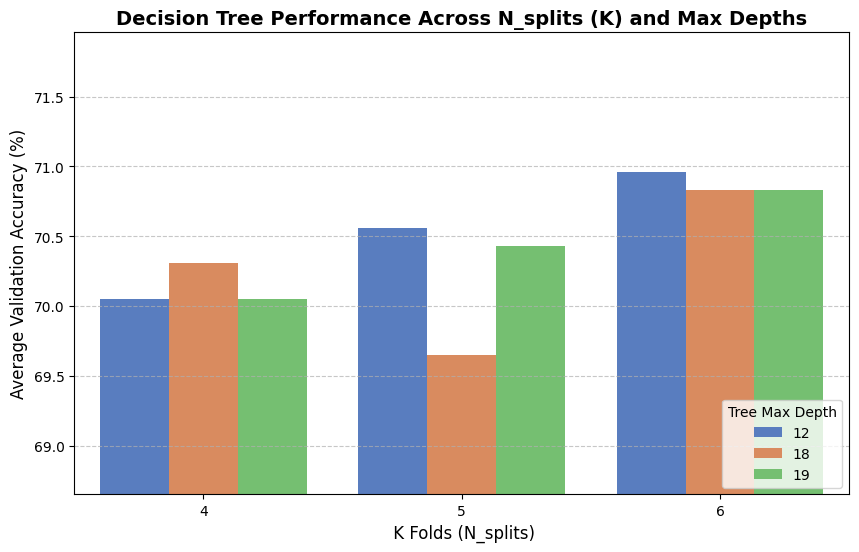

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_results, 
    x="N_splits (K)", 
    y="Avg Accuracy (%)", 
    hue="Max Depth", 
    palette="muted"
)

plt.title("Decision Tree Performance Across N_splits (K) and Max Depths", fontsize=14, fontweight='bold')
plt.xlabel(" K Folds (N_splits)", fontsize=12)
plt.ylabel("Average Validation Accuracy (%)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

min_acc = df_results["Avg Accuracy (%)"].min()
max_acc = df_results["Avg Accuracy (%)"].max()
plt.ylim(min_acc - 1, max_acc + 1)

plt.legend(title="Tree Max Depth", loc="lower right")
plt.show()
